# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 8 — Robustness, Costs & Sensitivity Analysis

Block 8 stress-tests the main finding from Blocks 6–7: whether the **state-dependent active overlay** adds value relative to both the strategic inverse-volatility baseline and conventional 12-month TSMOM.

The robustness programme covers:

- transaction costs at **0 / 5 / 10 / 20 bps**
- subperiod performance
- sensitivity to the state-dependent active-weight staircase
- sensitivity to the TSMOM active tilt magnitude
- an **equal-weight strategic-base** robustness test
- leave-one-sector-out tests
- active-contribution concentration diagnostics
- consistent robustness reporting of **CAGR, volatility, Sharpe, Sortino, maximum drawdown and Calmar**

The purpose is to test whether the result is persistent and structurally robust rather than dependent on one sector, one allocation base, or one exact parameter choice.

No indicator/state definitions are changed in this block.


In [1]:
# ============================================================
# BLOCK 8.1 — ENVIRONMENT, DRIVE & PRIOR MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "root": PROJECT_ROOT,
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "outputs": PROJECT_ROOT / "outputs",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

manifest_names = {
    "block1": "block_1_research_configuration.json",
    "block2": "block_2_universe_data_weights.json",
    "block3": "block_3_signal_engine.json",
    "block4": "block_4_state_active_weights.json",
    "block5": "block_5_portfolio_engine.json",
    "block6": "block_6_performance_analytics.json",
    "block7": "block_7_visual_diagnostics.json",
}

manifests = {}

for key, filename in manifest_names.items():
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(f"Required manifest not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        manifests[key] = json.load(f)

block1 = manifests["block1"]
block2 = manifests["block2"]
block3 = manifests["block3"]
block4 = manifests["block4"]
block5 = manifests["block5"]
block6 = manifests["block6"]
block7 = manifests["block7"]

CONFIG = block1["research_config"]
SECTOR_RECORDS = block1["sector_universe"]
SECTOR_TICKERS = [x["ticker"] for x in SECTOR_RECORDS]

assert len(SECTOR_TICKERS) == 11
assert block5["strategic_weight_method"] == "INVERSE_VOLATILITY_52W"

print("Loaded and validated Blocks 1–7.")


Mounted at /content/drive
Loaded and validated Blocks 1–7.


In [2]:
# ============================================================
# BLOCK 8.2 — IMPORTS & ROBUST INPUT LOADER
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)


def first_existing_path(mapping, candidate_keys, label):
    for key in candidate_keys:
        if key in mapping:
            p = Path(mapping[key])
            if p.exists():
                return p
    raise FileNotFoundError(
        f"Could not resolve {label}. Tried keys: {candidate_keys}"
    )


PORTFOLIO_RETURNS_PATH = first_existing_path(
    block5["saved_files"],
    ["portfolio_returns", "weekly_portfolio_returns_core_strategies"],
    "portfolio returns",
)

TURNOVER_PATH = first_existing_path(
    block5["saved_files"],
    ["portfolio_turnover", "weekly_portfolio_turnover_core_strategies"],
    "portfolio turnover",
)

SECTOR_RETURN_PATH = first_existing_path(
    block5["saved_files"],
    ["sector_holding_returns", "weekly_execution_holding_returns_sectors"],
    "sector holding returns",
)

TSMOM_WEIGHT_PATH = first_existing_path(
    block5["saved_files"],
    ["tsmom_target_weights", "weekly_tsmom_target_weights"],
    "TSMOM target weights",
)

STATE_WEIGHT_PATH = first_existing_path(
    block4["saved_files"],
    ["canonical_target_weights_wide", "target_weights", "weekly_state_dependent_target_weights"],
    "state-dependent target weights",
)

STATE_LONG_PATH = first_existing_path(
    block4["saved_files"],
    ["canonical_active_weights_long", "active_weights_long", "weekly_state_dependent_active_weights_long"],
    "state-dependent active-weight long file",
)

STRATEGIC_WEIGHT_PATH = first_existing_path(
    block2["saved_files"],
    ["strategic_weights", "weekly_strategic_weights"],
    "strategic weights",
)

portfolio_returns = pd.read_parquet(PORTFOLIO_RETURNS_PATH)
turnover = pd.read_parquet(TURNOVER_PATH)
sector_returns = pd.read_parquet(SECTOR_RETURN_PATH)
tsmom_weights = pd.read_parquet(TSMOM_WEIGHT_PATH)
state_weights = pd.read_parquet(STATE_WEIGHT_PATH)
state_long = pd.read_parquet(STATE_LONG_PATH)
strategic_weights = pd.read_parquet(STRATEGIC_WEIGHT_PATH)

for obj in [
    portfolio_returns,
    turnover,
    sector_returns,
    tsmom_weights,
    state_weights,
    strategic_weights,
]:
    obj.index = pd.to_datetime(obj.index)
    obj.sort_index(inplace=True)

state_long["date"] = pd.to_datetime(state_long["date"])
state_long.sort_values(["ticker", "date"], inplace=True)

REALIZED_INDEX = portfolio_returns.index
SECTOR_COLS = sector_returns.columns.tolist()

assert set(SECTOR_COLS) == set(SECTOR_TICKERS)
assert portfolio_returns.notna().all().all()

print(f"Realized weekly observations: {len(REALIZED_INDEX):,}")
print(f"Sector count: {len(SECTOR_COLS)}")


Realized weekly observations: 374
Sector count: 11


In [3]:
# ============================================================
# BLOCK 8.3 — COMMON METRIC FUNCTIONS
# ============================================================

PERIODS_PER_YEAR = 52
RISK_FREE_RATE_ANNUAL = 0.0

REALIZED_EXECUTION_START = pd.Timestamp(
    block6["realized_execution_window"]["start"]
)
REALIZED_EXECUTION_END = pd.Timestamp(
    block6["realized_execution_window"]["end"]
)

ELAPSED_YEARS = (
    (REALIZED_EXECUTION_END - REALIZED_EXECUTION_START).days
    / 365.2425
)


def cumulative_return(r):
    return float((1.0 + r).prod() - 1.0)


def cagr(r, years=None):
    if years is None:
        if len(r) <= 1:
            return np.nan
        years = (r.index[-1] - r.index[0]).days / 365.2425
        # Signal labels are weekly; add approximately one holding period
        # so short subperiod CAGR is not overstated.
        years += 7.0 / 365.2425
    terminal = float((1.0 + r).prod())
    if years <= 0 or terminal <= 0:
        return np.nan
    return terminal ** (1.0 / years) - 1.0


def ann_vol(r):
    return float(r.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR))


def sharpe(r):
    rf_weekly = (1.0 + RISK_FREE_RATE_ANNUAL) ** (1.0 / PERIODS_PER_YEAR) - 1.0
    excess = r - rf_weekly
    vol = excess.std(ddof=1)
    if vol == 0 or pd.isna(vol):
        return np.nan
    return float(excess.mean() / vol * np.sqrt(PERIODS_PER_YEAR))


def sortino(r):
    rf_weekly = (1.0 + RISK_FREE_RATE_ANNUAL) ** (1.0 / PERIODS_PER_YEAR) - 1.0
    excess = r - rf_weekly
    downside = excess[excess < 0]
    if len(downside) == 0:
        return np.nan
    downside_dev = np.sqrt((downside ** 2).mean())
    if downside_dev == 0 or pd.isna(downside_dev):
        return np.nan
    return float(excess.mean() / downside_dev * np.sqrt(PERIODS_PER_YEAR))


def drawdown_series(r):
    w = (1.0 + r).cumprod()
    return w / w.cummax() - 1.0


def max_drawdown(r):
    return float(drawdown_series(r).min())


def calmar(r):
    g = cagr(r)
    mdd = max_drawdown(r)
    if mdd == 0 or pd.isna(mdd):
        return np.nan
    return float(g / abs(mdd))


def information_ratio(active_return):
    te = active_return.std(ddof=1)
    if te == 0 or pd.isna(te):
        return np.nan
    return float(active_return.mean() / te * np.sqrt(PERIODS_PER_YEAR))


def summarize_return_series(r):
    return {
        "Cumulative Return": cumulative_return(r),
        "CAGR": cagr(r),
        "Annualized Volatility": ann_vol(r),
        "Sharpe": sharpe(r),
        "Sortino": sortino(r),
        "Max Drawdown": max_drawdown(r),
        "Calmar": calmar(r),
    }


def portfolio_return_from_weights(weights, returns):
    w = weights.reindex(index=returns.index, columns=returns.columns)
    if w.isna().any().any():
        raise ValueError("Missing weights in realized return window.")
    return (w * returns).sum(axis=1)


def normalize_rows(raw_weights):
    denom = raw_weights.sum(axis=1)
    if (denom <= 0).any():
        raise ValueError("Non-positive raw portfolio weight sum.")
    return raw_weights.div(denom, axis=0)


## Transaction-cost convention

Block 5 turnover is defined as one-way portfolio turnover:

\[
Turnover_t = \frac{1}{2}\sum_i |w_{i,t}-w_{i,t-1}|
\]

For a cost assumption of \(c\) basis points per dollar traded, the weekly cost deduction is:

\[
Cost_t = Turnover_t \times \frac{c}{10{,}000}
\]

The first portfolio-establishment trade remains excluded, consistently with Block 5's turnover convention.


In [4]:
# ============================================================
# BLOCK 8.4 — TRANSACTION-COST ROBUSTNESS
# ============================================================

COST_SCENARIOS_BPS = [0, 5, 10, 20]

cost_rows = []
net_return_sets = {}

for cost_bps in COST_SCENARIOS_BPS:
    net = portfolio_returns.copy()

    for strategy in ["Strategic_IV", "TSMOM_12M", "State_Dependent"]:
        strategy_turnover = turnover[strategy].reindex(net.index).fillna(0.0)
        net[strategy] = (
            net[strategy]
            - strategy_turnover * cost_bps / 10000.0
        )

    # SPY remains the passive benchmark and is not assigned synthetic
    # weekly trading costs here.
    net_return_sets[cost_bps] = net

    for strategy in ["Strategic_IV", "TSMOM_12M", "State_Dependent"]:
        r = net[strategy]

        row = {
            "Cost_bps": cost_bps,
            "Strategy": strategy,
            "Cumulative Return": cumulative_return(r),
            "CAGR": cagr(r),
            "Annualized Volatility": ann_vol(r),
            "Sharpe": sharpe(r),
            "Sortino": sortino(r),
            "Max Drawdown": max_drawdown(r),
            "Calmar": calmar(r),
            "Terminal Wealth": float((1.0 + r).prod()),
        }

        if strategy in ["TSMOM_12M", "State_Dependent"]:
            row["IR_vs_Strategic"] = information_ratio(
                r - net["Strategic_IV"]
            )
        else:
            row["IR_vs_Strategic"] = np.nan

        row["IR_vs_SPY"] = (
            information_ratio(r - net["SPY"])
            if strategy != "SPY"
            else np.nan
        )

        cost_rows.append(row)

cost_robustness = (
    pd.DataFrame(cost_rows)
    .set_index(["Cost_bps", "Strategy"])
)

display(cost_robustness)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  IR_vs_Strategic  IR_vs_SPY
Cost_bps Strategy                                                                                                                                                    
0        Strategic_IV              1.343816  0.126183               0.171515  0.777031  0.680130     -0.351040  0.359454         2.343816              NaN  -0.521742
         TSMOM_12M                 1.350249  0.126613               0.168967  0.788368  0.694136     -0.345465  0.366501         2.350249        -0.007002  -0.524259
         State_Dependent           1.559913  0.140125               0.173575  0.840655  0.741352     -0.351040  0.399170         2.559913         0.781392  -0.298084
5        Strategic_IV              1.341209  0.126008               0.171514  0.776129  0.681732     -0.351073  0.358921         2.341209              NaN  -0.524313
         TSMOM_12M                 1.338844  0.125849               0.168957  0.784397  0.690363     -0.345534  0.364215         2.338844        -0.064503  -0.535539
         State_Dependent           1.554287  0.139775               0.173573  0.838896  0.739687     -0.351073  0.398135         2.554287         0.771966  -0.302969
10       Strategic_IV              1.338605  0.125833               0.171514  0.775228  0.680875     -0.351107  0.358389         2.338605              NaN  -0.526884
         TSMOM_12M                 1.327494  0.125085               0.168946  0.780425  0.686592     -0.345604  0.361932         2.327494        -0.122027  -0.546815
         State_Dependent           1.548673  0.139425               0.173572  0.837136  0.738024     -0.351107  0.397101         2.548673         0.762537  -0.307852
20       Strategic_IV              1.333406  0.125483               0.171512  0.773425  0.679160     -0.351174  0.357325         2.333406              NaN  -0.532026
         TSMOM_12M                 1.304957  0.123559               0.168926  0.772478  0.681496     -0.345742  0.357373         2.304957        -0.237060  -0.569353
         State_Dependent           1.537482  0.138726               0.173568  0.833618  0.734697     -0.351174  0.395034         2.537482         0.743672  -0.317618

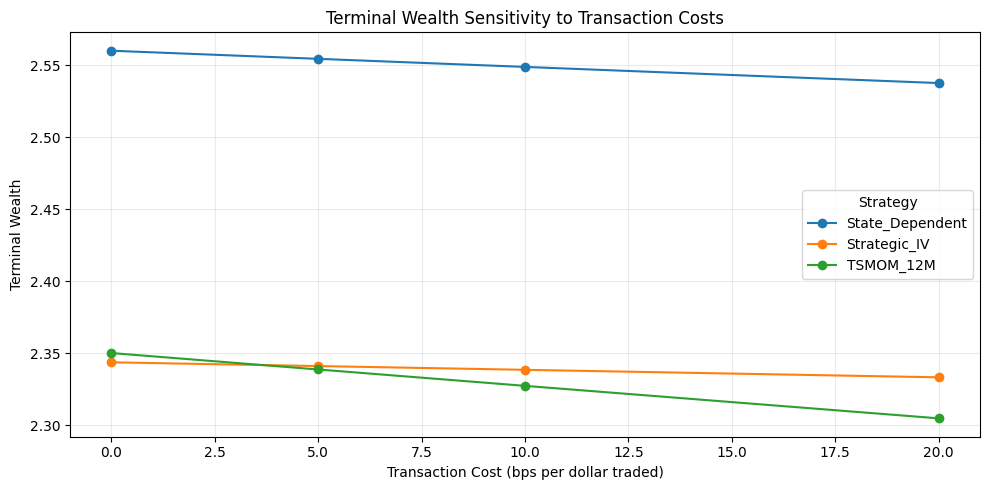

In [5]:
# ============================================================
# BLOCK 8.5 — FIGURE: COST SENSITIVITY
# ============================================================

cost_plot = (
    cost_robustness["Terminal Wealth"]
    .unstack("Strategy")
)

fig, ax = plt.subplots(figsize=(10, 5))
cost_plot.plot(marker="o", ax=ax)

ax.set_title("Terminal Wealth Sensitivity to Transaction Costs")
ax.set_xlabel("Transaction Cost (bps per dollar traded)")
ax.set_ylabel("Terminal Wealth")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG_COST = DIRS["figures"] / "block_8_cost_sensitivity.png"
fig.savefig(FIG_COST, dpi=180, bbox_inches="tight")
plt.show()


In [6]:
# ============================================================
# BLOCK 8.6 — SUBPERIOD ROBUSTNESS
# ============================================================

# Non-overlapping research subperiods chosen ex ante for diagnostics:
# 1) inception through 2021
# 2) 2022–2023
# 3) 2024 onward
SUBPERIODS = {
    "2019-2021": ("2019-06-21", "2021-12-31"),
    "2022-2023": ("2022-01-01", "2023-12-31"),
    "2024-End": ("2024-01-01", str(REALIZED_INDEX.max().date())),
}

subperiod_rows = []

for period_name, (start, end) in SUBPERIODS.items():
    sample = portfolio_returns.loc[start:end]

    if len(sample) < 10:
        continue

    for strategy in ["SPY", "Strategic_IV", "TSMOM_12M", "State_Dependent"]:
        r = sample[strategy]

        row = {
            "Subperiod": period_name,
            "Strategy": strategy,
            **summarize_return_series(r),
        }

        if strategy != "SPY":
            row["IR_vs_SPY"] = information_ratio(
                r - sample["SPY"]
            )
        else:
            row["IR_vs_SPY"] = np.nan

        if strategy in ["TSMOM_12M", "State_Dependent"]:
            row["IR_vs_Strategic"] = information_ratio(
                r - sample["Strategic_IV"]
            )
        else:
            row["IR_vs_Strategic"] = np.nan

        subperiod_rows.append(row)

subperiod_summary = (
    pd.DataFrame(subperiod_rows)
    .set_index(["Subperiod", "Strategy"])
)

display(subperiod_summary)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  IR_vs_SPY  IR_vs_Strategic
Subperiod Strategy                                                                                                                                   
2019-2021 SPY                       0.652080  0.217689               0.216967  1.013794  0.890711     -0.334003  0.651756        NaN              NaN
          Strategic_IV              0.546883  0.186660               0.217894  0.891824  0.763013     -0.351040  0.531735  -0.589469              NaN
          TSMOM_12M                 0.542484  0.185335               0.214257  0.897978  0.778286     -0.345465  0.536480  -0.654803        -0.182644
          State_Dependent           0.591980  0.200114               0.219909  0.936869  0.798431     -0.351040  0.570061  -0.266500         0.696973
2022-2023 SPY                       0.051814  0.025668               0.183128  0.229334  0.212319     -0.205209  0.125083        NaN              NaN
          Strategic_IV              0.030360  0.015118               0.165489  0.173183  0.157445     -0.182549  0.082818  -0.277957              NaN
          TSMOM_12M                 0.039040  0.019400               0.162178  0.199222  0.181907     -0.177535  0.109273  -0.192367         0.334017
          State_Dependent           0.054859  0.027157               0.168747  0.242851  0.225136     -0.176648  0.153736  -0.021178         0.658513
2024-End  SPY                       0.657188  0.212131               0.153895  1.324852  1.334292     -0.172681  1.228453        NaN              NaN
          Strategic_IV              0.470541  0.158204               0.116703  1.314594  1.116441     -0.126707  1.248578  -0.636520              NaN
          TSMOM_12M                 0.466429  0.156969               0.116637  1.306125  1.109371     -0.125959  1.246193  -0.656282        -0.198162
          State_Dependent           0.524379  0.174174               0.117852  1.418920  1.223330     -0.119879  1.452909  -0.460234         1.030652

## State-dependent staircase sensitivity

The indicator states are held fixed. Only the **portfolio translation layer** is varied.

This isolates the economic importance of the active-weight implementation from the signal-generation logic itself. For each sector, the active multiplier is recursively reconstructed using the same rules as the canonical portfolio:

- bearish → minimum active weight
- confirmed trend → neutral
- early reversal → rebuild by one step toward neutral
- pullback accumulation → add one step toward the maximum overweight
- profit taking → remove one step toward neutral
- normal positive trend → retain the prior active multiplier

The test varies the maximum absolute active bound and the staircase step size.


In [7]:
# ============================================================
# BLOCK 8.7 — RECONSTRUCT ACTIVE MULTIPLIERS FOR SENSITIVITY
# ============================================================

required_state_cols = {
    "date",
    "ticker",
    "strategic_state",
    "tactical_state",
}

missing_state_cols = required_state_cols.difference(state_long.columns)
if missing_state_cols:
    raise ValueError(
        f"State long file is missing required columns: {sorted(missing_state_cols)}"
    )


def rebuild_active_multipliers(state_df, active_bound, active_step):
    out = []

    for ticker, g in state_df.groupby("ticker", sort=False):
        g = g.sort_values("date").copy()
        a_prev = 0.0

        for row in g.itertuples(index=False):
            strategic_state = row.strategic_state
            tactical_state = row.tactical_state

            if strategic_state == "BEARISH":
                a = -active_bound

            elif strategic_state == "CONFIRMED_TREND":
                a = 0.0

            elif strategic_state == "EARLY_REVERSAL":
                a = min(0.0, a_prev + active_step)

            elif tactical_state == "PULLBACK_ACCUMULATION":
                a = min(active_bound, a_prev + active_step)

            elif tactical_state == "PROFIT_TAKING":
                a = max(0.0, a_prev - active_step)

            elif strategic_state == "NORMAL_POSITIVE_TREND":
                a = min(active_bound, max(0.0, a_prev))

            else:
                # Defensive fallback for any unrecognized held-state label:
                # preserve the prior multiplier.
                a = a_prev

            # Remove floating-point staircase noise.
            a = float(np.round(a, 10))

            out.append(
                {
                    "date": row.date,
                    "ticker": ticker,
                    "active_multiplier": a,
                }
            )
            a_prev = a

    return pd.DataFrame(out)


def active_long_to_weights(active_long, strategic_w):
    active_wide = (
        active_long
        .pivot(index="date", columns="ticker", values="active_multiplier")
        .sort_index()
    )

    base = strategic_w.reindex(
        index=active_wide.index,
        columns=active_wide.columns,
    )

    if base.isna().any().any():
        raise ValueError("Missing strategic weights during sensitivity rebuild.")

    raw = base * (1.0 + active_wide)
    return normalize_rows(raw)


canonical_rebuild_long = rebuild_active_multipliers(
    state_long,
    active_bound=0.50,
    active_step=0.10,
)

canonical_rebuild_weights = active_long_to_weights(
    canonical_rebuild_long,
    strategic_weights,
)

common_check_index = state_weights.index.intersection(
    canonical_rebuild_weights.index
)

canonical_diff = (
    canonical_rebuild_weights.reindex(common_check_index)[SECTOR_COLS]
    - state_weights.reindex(common_check_index)[SECTOR_COLS]
).abs().max().max()

print(f"Maximum canonical weight reconstruction difference: {canonical_diff:.3e}")

if canonical_diff > 1e-8:
    raise AssertionError(
        "Canonical active-weight reconstruction does not match Block 4. "
        "Sensitivity analysis stopped to avoid testing a mismatched engine."
    )


Maximum canonical weight reconstruction difference: 5.551e-17


In [8]:
# ============================================================
# BLOCK 8.8 — ACTIVE-BOUND / STEP SENSITIVITY GRID
# ============================================================

ACTIVE_BOUNDS = [0.25, 0.50, 0.75]
ACTIVE_STEPS = [0.05, 0.10, 0.15]

sensitivity_rows = []
sensitivity_return_sets = {}

for bound in ACTIVE_BOUNDS:
    for step in ACTIVE_STEPS:
        active_long_cf = rebuild_active_multipliers(
            state_long,
            active_bound=bound,
            active_step=step,
        )

        weights_cf = active_long_to_weights(
            active_long_cf,
            strategic_weights,
        ).reindex(REALIZED_INDEX)[SECTOR_COLS]

        r_cf = portfolio_return_from_weights(
            weights_cf,
            sector_returns[SECTOR_COLS],
        )

        sensitivity_return_sets[(bound, step)] = r_cf

        active_vs_strategic = (
            r_cf - portfolio_returns["Strategic_IV"]
        )
        active_vs_tsmom = (
            r_cf - portfolio_returns["TSMOM_12M"]
        )

        sensitivity_rows.append(
            {
                "Active_Bound": bound,
                "Active_Step": step,
                "CAGR": cagr(r_cf),
                "Annualized Volatility": ann_vol(r_cf),
                "Sharpe": sharpe(r_cf),
                "Sortino": sortino(r_cf),
                "Max Drawdown": max_drawdown(r_cf),
                "Calmar": calmar(r_cf),
                "IR_vs_Strategic": information_ratio(active_vs_strategic),
                "IR_vs_TSMOM": information_ratio(active_vs_tsmom),
                "Terminal Wealth": float((1.0 + r_cf).prod()),
            }
        )

state_parameter_sensitivity = (
    pd.DataFrame(sensitivity_rows)
    .set_index(["Active_Bound", "Active_Step"])
)

display(state_parameter_sensitivity)


CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  IR_vs_Strategic  IR_vs_TSMOM  Terminal Wealth
Active_Bound Active_Step                                                                                                                            
0.25         0.05         0.132449               0.172240  0.806656  0.716171      -0.35104  0.377306         0.800169     0.517535         2.438924
             0.10         0.132229               0.172337  0.805176  0.712197      -0.35104  0.376678         0.767267     0.497992         2.435525
             0.15         0.132218               0.172364  0.805016  0.712038      -0.35104  0.376645         0.770769     0.498070         2.435347
0.50         0.05         0.138509               0.173211  0.833881  0.739977      -0.35104  0.394567         0.729452     0.653144         2.534022
             0.10         0.140125               0.173575  0.840655  0.741352      -0.35104  0.399170         0.781392     0.706373         2.559913
             0.15         0.139764               0.173710  0.838320  0.739192      -0.35104  0.398144         0.757752     0.685004         2.554119
0.75         0.05         0.146034               0.175595  0.862426  0.773329      -0.35104  0.416004         0.645415     0.629911         2.656554
             0.10         0.150040               0.176093  0.880280  0.790646      -0.35104  0.427415         0.728760     0.710655         2.723827
             0.15         0.150570               0.176423  0.881571  0.789368      -0.35104  0.428925         0.733446     0.716158         2.732841

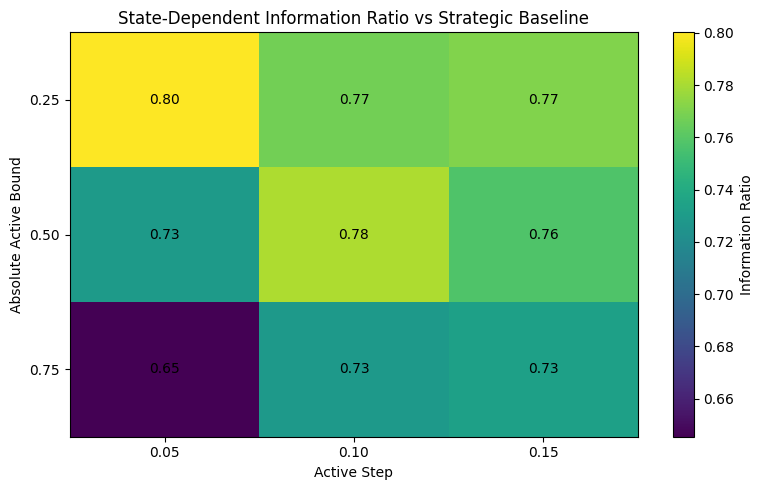

In [9]:
# ============================================================
# BLOCK 8.9 — FIGURE: STATE PARAMETER SENSITIVITY
# ============================================================

heat = (
    state_parameter_sensitivity["IR_vs_Strategic"]
    .unstack("Active_Step")
)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heat.values, aspect="auto")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"{x:.2f}" for x in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([f"{x:.2f}" for x in heat.index])

ax.set_xlabel("Active Step")
ax.set_ylabel("Absolute Active Bound")
ax.set_title("State-Dependent Information Ratio vs Strategic Baseline")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(
            j,
            i,
            f"{heat.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(im, ax=ax, label="Information Ratio")
fig.tight_layout()

FIG_STATE_SENS = DIRS["figures"] / "block_8_state_parameter_sensitivity.png"
fig.savefig(FIG_STATE_SENS, dpi=180, bbox_inches="tight")
plt.show()


In [10]:
# ============================================================
# BLOCK 8.10 — TSMOM TILT SENSITIVITY
# ============================================================

TSMOM_SIGN_PATH = first_existing_path(
    block3["saved_files"],
    ["tsmom_signs", "weekly_tsmom_signs", "weekly_tsmom_12m_signs"],
    "TSMOM sign matrix",
)

tsmom_signs = pd.read_parquet(TSMOM_SIGN_PATH)
tsmom_signs.index = pd.to_datetime(tsmom_signs.index)
tsmom_signs.sort_index(inplace=True)

TSMOM_TILTS = [0.10, 0.25, 0.40, 0.50]

tsmom_sensitivity_rows = []

for tilt in TSMOM_TILTS:
    signs = tsmom_signs.reindex(
        index=REALIZED_INDEX,
        columns=SECTOR_COLS,
    )

    if signs.isna().any().any():
        raise ValueError("Missing TSMOM signs in realized sensitivity window.")

    base = strategic_weights.reindex(
        index=REALIZED_INDEX,
        columns=SECTOR_COLS,
    )

    raw = base * (1.0 + tilt * signs)
    w = normalize_rows(raw)

    r = portfolio_return_from_weights(
        w,
        sector_returns[SECTOR_COLS],
    )

    tsmom_sensitivity_rows.append(
        {
            "TSMOM_Tilt": tilt,
            "CAGR": cagr(r),
            "Annualized Volatility": ann_vol(r),
            "Sharpe": sharpe(r),
            "Sortino": sortino(r),
            "Max Drawdown": max_drawdown(r),
            "Calmar": calmar(r),
            "IR_vs_Strategic": information_ratio(
                r - portfolio_returns["Strategic_IV"]
            ),
            "Terminal Wealth": float((1.0 + r).prod()),
        }
    )

tsmom_tilt_sensitivity = (
    pd.DataFrame(tsmom_sensitivity_rows)
    .set_index("TSMOM_Tilt")
)

display(tsmom_tilt_sensitivity)


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,IR_vs_Strategic,Terminal Wealth
TSMOM_Tilt,,,,,,,,
0.10,0.126491,0.170390,0.782603,0.688166,-0.348586,0.362868,0.020183,2.348416
0.25,0.126613,0.168967,0.788368,0.694136,-0.345465,0.366501,-0.007002,2.350249
0.40,0.126381,0.167818,0.791350,0.695075,-0.342893,0.368572,-0.032624,2.346777
0.50,0.126070,0.167198,0.791997,0.696214,-0.341429,0.369243,-0.047486,2.342145


## Alternative strategic base: equal-weight sectors

The canonical framework uses 52-week inverse-volatility strategic weights. To test whether the signal architecture itself is useful, Block 8 applies the **same realized state-dependent active multipliers** and TSMOM signs to a simple equal-weight sector base.

This is not proposed as a replacement benchmark. It is a robustness test intended to distinguish signal value from strategic-allocation effects.


In [11]:
# ============================================================
# BLOCK 8.11 — EQUAL-WEIGHT STRATEGIC-BASE ROBUSTNESS
# ============================================================

equal_base = pd.DataFrame(
    1.0 / len(SECTOR_COLS),
    index=REALIZED_INDEX,
    columns=SECTOR_COLS,
)

# Canonical state-dependent active multipliers.
canonical_active_wide = (
    canonical_rebuild_long
    .pivot(index="date", columns="ticker", values="active_multiplier")
    .reindex(index=REALIZED_INDEX, columns=SECTOR_COLS)
)

if canonical_active_wide.isna().any().any():
    raise ValueError("Missing canonical active multipliers for equal-weight test.")

state_equal_raw = equal_base * (1.0 + canonical_active_wide)
state_equal_weights = normalize_rows(state_equal_raw)

state_equal_returns = portfolio_return_from_weights(
    state_equal_weights,
    sector_returns[SECTOR_COLS],
)

# Equal-weight TSMOM using canonical 25% tilt.
signs_realized = tsmom_signs.reindex(
    index=REALIZED_INDEX,
    columns=SECTOR_COLS,
)

tsmom_equal_raw = equal_base * (1.0 + 0.25 * signs_realized)
tsmom_equal_weights = normalize_rows(tsmom_equal_raw)

tsmom_equal_returns = portfolio_return_from_weights(
    tsmom_equal_weights,
    sector_returns[SECTOR_COLS],
)

equal_base_returns = portfolio_return_from_weights(
    equal_base,
    sector_returns[SECTOR_COLS],
)

equal_weight_robustness = pd.DataFrame(
    {
        "Equal_Weight": summarize_return_series(equal_base_returns),
        "Equal_Weight_TSMOM": summarize_return_series(tsmom_equal_returns),
        "Equal_Weight_State": summarize_return_series(state_equal_returns),
    }
).T

equal_weight_robustness["IR_vs_Equal_Weight"] = [
    np.nan,
    information_ratio(tsmom_equal_returns - equal_base_returns),
    information_ratio(state_equal_returns - equal_base_returns),
]

display(equal_weight_robustness)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,IR_vs_Equal_Weight
Equal_Weight,1.465747,0.134179,0.177842,0.795329,0.704193,-0.361765,0.370900,NaN
Equal_Weight_TSMOM,1.489165,0.135675,0.174975,0.812912,0.727090,-0.354568,0.382650,0.078596
Equal_Weight_State,1.707131,0.149053,0.180251,0.859302,0.772132,-0.361765,0.412017,0.732708


In [12]:
# ============================================================
# BLOCK 8.12 — LEAVE-ONE-SECTOR-OUT ROBUSTNESS
# ============================================================

strategic_realized = strategic_weights.reindex(
    index=REALIZED_INDEX,
    columns=SECTOR_COLS,
)

state_active_realized = canonical_active_wide.copy()
tsmom_sign_realized = signs_realized.copy()

loo_rows = []

for excluded in SECTOR_COLS:
    keep = [x for x in SECTOR_COLS if x != excluded]

    strategic_loo = normalize_rows(
        strategic_realized[keep]
    )

    state_raw_loo = (
        strategic_loo
        * (1.0 + state_active_realized[keep])
    )
    state_w_loo = normalize_rows(state_raw_loo)

    tsmom_raw_loo = (
        strategic_loo
        * (1.0 + 0.25 * tsmom_sign_realized[keep])
    )
    tsmom_w_loo = normalize_rows(tsmom_raw_loo)

    sector_r_loo = sector_returns[keep]

    strategic_r_loo = portfolio_return_from_weights(
        strategic_loo,
        sector_r_loo,
    )
    state_r_loo = portfolio_return_from_weights(
        state_w_loo,
        sector_r_loo,
    )
    tsmom_r_loo = portfolio_return_from_weights(
        tsmom_w_loo,
        sector_r_loo,
    )

    loo_rows.append(
        {
            "Excluded_Sector": excluded,
            "State_IR_vs_Strategic": information_ratio(
                state_r_loo - strategic_r_loo
            ),
            "TSMOM_IR_vs_Strategic": information_ratio(
                tsmom_r_loo - strategic_r_loo
            ),
            "State_IR_vs_TSMOM": information_ratio(
                state_r_loo - tsmom_r_loo
            ),
            "State_CAGR": cagr(state_r_loo),
            "State_Sharpe": sharpe(state_r_loo),
            "State_Sortino": sortino(state_r_loo),
            "State_Max_Drawdown": max_drawdown(state_r_loo),
            "State_Calmar": calmar(state_r_loo),
            "TSMOM_CAGR": cagr(tsmom_r_loo),
            "Strategic_CAGR": cagr(strategic_r_loo),
            "State_Terminal_Wealth": float((1.0 + state_r_loo).prod()),
        }
    )

leave_one_out_summary = (
    pd.DataFrame(loo_rows)
    .set_index("Excluded_Sector")
    .sort_index()
)

display(leave_one_out_summary)


,State_IR_vs_Strategic,TSMOM_IR_vs_Strategic,State_IR_vs_TSMOM,State_CAGR,State_Sharpe,State_Sortino,State_Max_Drawdown,State_Calmar,TSMOM_CAGR,Strategic_CAGR,State_Terminal_Wealth
Excluded_Sector,,,,,,,,,,,
XLB,0.829116,0.019614,0.727935,0.141904,0.856044,0.755967,-0.350249,0.405153,0.127633,0.126922,2.588692
XLC,0.579205,-0.056435,0.546890,0.135927,0.809639,0.726928,-0.357436,0.380284,0.125157,0.125219,2.493121
XLE,0.675355,-0.193172,0.709938,0.134836,0.821260,0.732126,-0.334782,0.402758,0.122978,0.124347,2.476006
XLF,0.888595,0.041780,0.793090,0.140804,0.855094,0.764704,-0.344395,0.408845,0.125446,0.124540,2.570870
XLI,0.764868,0.012408,0.686118,0.139170,0.845590,0.750581,-0.344607,0.403851,0.124936,0.124328,2.544586
XLK,0.919537,-0.135828,0.878784,0.130568,0.792384,0.704929,-0.356178,0.366580,0.113923,0.114844,2.410026
XLP,0.708462,0.111421,0.602937,0.146012,0.835190,0.742207,-0.364376,0.400717,0.134079,0.132487,2.656181
XLRE,0.730283,0.050241,0.638949,0.146789,0.877971,0.792906,-0.347387,0.422553,0.132861,0.131755,2.669128
XLU,0.726076,0.059012,0.624343,0.141675,0.841350,0.753033,-0.351482,0.403080,0.129582,0.128428,2.584972


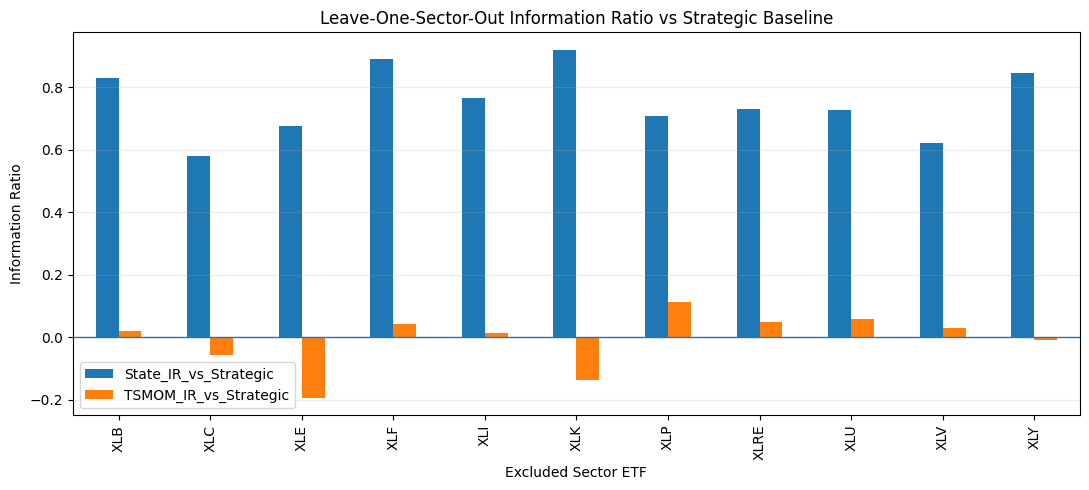

In [13]:
# ============================================================
# BLOCK 8.13 — FIGURE: LEAVE-ONE-SECTOR-OUT IR
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))

leave_one_out_summary[
    ["State_IR_vs_Strategic", "TSMOM_IR_vs_Strategic"]
].plot(kind="bar", ax=ax)

ax.axhline(0.0, linewidth=1)
ax.set_title("Leave-One-Sector-Out Information Ratio vs Strategic Baseline")
ax.set_xlabel("Excluded Sector ETF")
ax.set_ylabel("Information Ratio")
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()

FIG_LOO = DIRS["figures"] / "block_8_leave_one_sector_out.png"
fig.savefig(FIG_LOO, dpi=180, bbox_inches="tight")
plt.show()


In [14]:
# ============================================================
# BLOCK 8.14 — CONTRIBUTION CONCENTRATION
# ============================================================

STATE_ATTRIB_PATH = first_existing_path(
    block6["saved_files"],
    ["state_sector_attribution_weekly"],
    "weekly state-sector attribution",
)

state_sector_contrib = pd.read_parquet(STATE_ATTRIB_PATH)
state_sector_contrib.index = pd.to_datetime(state_sector_contrib.index)
state_sector_contrib.sort_index(inplace=True)

total_contrib = state_sector_contrib.sum(axis=0)
positive_contrib = total_contrib[total_contrib > 0].sort_values(ascending=False)
absolute_contrib = total_contrib.abs().sort_values(ascending=False)

concentration = pd.Series(
    {
        "Net active contribution": total_contrib.sum(),
        "Largest sector contribution": total_contrib.max(),
        "Smallest sector contribution": total_contrib.min(),
        "Top 1 share of positive contribution": (
            positive_contrib.iloc[:1].sum() / positive_contrib.sum()
            if positive_contrib.sum() != 0 else np.nan
        ),
        "Top 3 share of positive contribution": (
            positive_contrib.iloc[:3].sum() / positive_contrib.sum()
            if positive_contrib.sum() != 0 else np.nan
        ),
        "Top 3 share of absolute contribution": (
            absolute_contrib.iloc[:3].sum() / absolute_contrib.sum()
            if absolute_contrib.sum() != 0 else np.nan
        ),
        "Positive contributing sectors": int((total_contrib > 0).sum()),
        "Negative contributing sectors": int((total_contrib < 0).sum()),
    },
    name="Contribution concentration",
).to_frame()

display(concentration)


,Contribution concentration
Net active contribution,0.090944
Largest sector contribution,0.043663
Smallest sector contribution,-0.023141
Top 1 share of positive contribution,0.309403
Top 3 share of positive contribution,0.785136
Top 3 share of absolute contribution,0.579201
Positive contributing sectors,7.000000
Negative contributing sectors,4.000000


In [15]:
# ============================================================
# BLOCK 8.15 — ROBUSTNESS SCORECARD
# ============================================================

canonical_state_ir = information_ratio(
    portfolio_returns["State_Dependent"]
    - portfolio_returns["Strategic_IV"]
)

canonical_tsmom_ir = information_ratio(
    portfolio_returns["TSMOM_12M"]
    - portfolio_returns["Strategic_IV"]
)

state_wins_subperiods = 0
subperiod_count = 0

for period_name in SUBPERIODS:
    try:
        s = subperiod_summary.loc[period_name]
        state_ir = s.loc["State_Dependent", "IR_vs_Strategic"]
        tsmom_ir = s.loc["TSMOM_12M", "IR_vs_Strategic"]
        if pd.notna(state_ir) and pd.notna(tsmom_ir):
            subperiod_count += 1
            state_wins_subperiods += int(state_ir > tsmom_ir)
    except KeyError:
        pass

loo_positive = int(
    (leave_one_out_summary["State_IR_vs_Strategic"] > 0).sum()
)

scorecard = pd.Series(
    {
        "Canonical State IR vs Strategic": canonical_state_ir,
        "Canonical TSMOM IR vs Strategic": canonical_tsmom_ir,
        "State IR exceeds TSMOM IR": canonical_state_ir > canonical_tsmom_ir,
        "State beats TSMOM IR in subperiods": (
            f"{state_wins_subperiods}/{subperiod_count}"
        ),
        "Leave-one-out cases with positive State IR": (
            f"{loo_positive}/{len(leave_one_out_summary)}"
        ),
        "Equal-weight State IR vs base": (
            equal_weight_robustness.loc[
                "Equal_Weight_State",
                "IR_vs_Equal_Weight",
            ]
        ),
        "Equal-weight TSMOM IR vs base": (
            equal_weight_robustness.loc[
                "Equal_Weight_TSMOM",
                "IR_vs_Equal_Weight",
            ]
        ),
        "5 bps State terminal wealth": (
            cost_robustness.loc[
                (5, "State_Dependent"),
                "Terminal Wealth",
            ]
        ),
        "5 bps TSMOM terminal wealth": (
            cost_robustness.loc[
                (5, "TSMOM_12M"),
                "Terminal Wealth",
            ]
        ),
    },
    name="Block 8 robustness scorecard",
).to_frame()

display(scorecard)


,Block 8 robustness scorecard
Canonical State IR vs Strategic,0.781392
Canonical TSMOM IR vs Strategic,-0.007002
State IR exceeds TSMOM IR,True
State beats TSMOM IR in subperiods,3/3
Leave-one-out cases with positive State IR,11/11
Equal-weight State IR vs base,0.732708
Equal-weight TSMOM IR vs base,0.078596
5 bps State terminal wealth,2.554287
5 bps TSMOM terminal wealth,2.338844


In [16]:
# ============================================================
# BLOCK 8.16 — CANONICAL GROSS / 5 BPS NET PERFORMANCE
# ============================================================

canonical_compare_rows = []

for label, cost_bps in [("Gross", 0), ("Net_5bps", 5)]:
    net = net_return_sets[cost_bps]

    for strategy in ["SPY", "Strategic_IV", "TSMOM_12M", "State_Dependent"]:
        r = net[strategy]
        row = {
            "Case": label,
            "Strategy": strategy,
            **summarize_return_series(r),
            "Terminal Wealth": float((1.0 + r).prod()),
        }

        if strategy in ["TSMOM_12M", "State_Dependent"]:
            row["IR_vs_Strategic"] = information_ratio(
                r - net["Strategic_IV"]
            )
        else:
            row["IR_vs_Strategic"] = np.nan

        if strategy != "SPY":
            row["IR_vs_SPY"] = information_ratio(
                r - net["SPY"]
            )
        else:
            row["IR_vs_SPY"] = np.nan

        canonical_compare_rows.append(row)

canonical_gross_net_summary = (
    pd.DataFrame(canonical_compare_rows)
    .set_index(["Case", "Strategy"])
)

display(canonical_gross_net_summary)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  IR_vs_Strategic  IR_vs_SPY
Case     Strategy                                                                                                                                                    
Gross    SPY                       1.879664  0.159001               0.186192  0.883955  0.825773     -0.334003  0.476045         2.879664              NaN        NaN
         Strategic_IV              1.343816  0.126183               0.171515  0.777031  0.680130     -0.351040  0.359454         2.343816              NaN  -0.521742
         TSMOM_12M                 1.350249  0.126613               0.168967  0.788368  0.694136     -0.345465  0.366501         2.350249        -0.007002  -0.524259
         State_Dependent           1.559913  0.140125               0.173575  0.840655  0.741352     -0.351040  0.399170         2.559913         0.781392  -0.298084
Net_5bps SPY                       1.879664  0.159001               0.186192  0.883955  0.825773     -0.334003  0.476045         2.879664              NaN        NaN
         Strategic_IV              1.341209  0.126008               0.171514  0.776129  0.681732     -0.351073  0.358921         2.341209              NaN  -0.524313
         TSMOM_12M                 1.338844  0.125849               0.168957  0.784397  0.690363     -0.345534  0.364215         2.338844        -0.064503  -0.535539
         State_Dependent           1.554287  0.139775               0.173573  0.838896  0.739687     -0.351073  0.398135         2.554287         0.771966  -0.302969

In [17]:
# ============================================================
# BLOCK 8.17 — SAVE TABLES
# ============================================================

TABLE_PATHS = {
    "cost_robustness": DIRS["tables"] / "block_8_cost_robustness.csv",
    "subperiod_summary": DIRS["tables"] / "block_8_subperiod_summary.csv",
    "state_parameter_sensitivity": DIRS["tables"] / "block_8_state_parameter_sensitivity.csv",
    "tsmom_tilt_sensitivity": DIRS["tables"] / "block_8_tsmom_tilt_sensitivity.csv",
    "equal_weight_robustness": DIRS["tables"] / "block_8_equal_weight_robustness.csv",
    "leave_one_out": DIRS["tables"] / "block_8_leave_one_sector_out.csv",
    "contribution_concentration": DIRS["tables"] / "block_8_contribution_concentration.csv",
    "robustness_scorecard": DIRS["tables"] / "block_8_robustness_scorecard.csv",
    "canonical_gross_net": DIRS["tables"] / "block_8_canonical_gross_net_performance.csv",
}

cost_robustness.to_csv(TABLE_PATHS["cost_robustness"])
subperiod_summary.to_csv(TABLE_PATHS["subperiod_summary"])
state_parameter_sensitivity.to_csv(TABLE_PATHS["state_parameter_sensitivity"])
tsmom_tilt_sensitivity.to_csv(TABLE_PATHS["tsmom_tilt_sensitivity"])
equal_weight_robustness.to_csv(TABLE_PATHS["equal_weight_robustness"])
leave_one_out_summary.to_csv(TABLE_PATHS["leave_one_out"])
concentration.to_csv(TABLE_PATHS["contribution_concentration"])
scorecard.to_csv(TABLE_PATHS["robustness_scorecard"])
canonical_gross_net_summary.to_csv(TABLE_PATHS["canonical_gross_net"])

print("Saved Block 8 robustness tables.")


Saved Block 8 robustness tables.


In [18]:
# ============================================================
# BLOCK 8.18 — SAVE BLOCK 8 MANIFEST
# ============================================================

block8_manifest = {
    "project": block1["project"],
    "block": "Block 8 - Robustness, Costs & Sensitivity Analysis",
    "created_utc": datetime.now(timezone.utc).isoformat(),

    "transaction_cost_scenarios_bps": COST_SCENARIOS_BPS,
    "risk_free_rate_annual": RISK_FREE_RATE_ANNUAL,
    "subperiods": SUBPERIODS,
    "state_active_bounds_tested": ACTIVE_BOUNDS,
    "state_active_steps_tested": ACTIVE_STEPS,
    "tsmom_tilts_tested": TSMOM_TILTS,

    "robustness_tests": [
        "Transaction costs",
        "Subperiod analysis",
        "State active-bound and staircase-step sensitivity",
        "TSMOM tilt sensitivity",
        "Equal-weight strategic-base test",
        "Leave-one-sector-out test",
        "Contribution concentration",
    ],

    "canonical_reconstruction_max_weight_difference": float(canonical_diff),

    "tables": {
        key: str(path)
        for key, path in TABLE_PATHS.items()
    },

    "figures": {
        "cost_sensitivity": str(FIG_COST),
        "state_parameter_sensitivity": str(FIG_STATE_SENS),
        "leave_one_sector_out": str(FIG_LOO),
    },
}

BLOCK8_MANIFEST = (
    DIRS["manifests"] / "block_8_robustness_costs_sensitivity.json"
)

with open(BLOCK8_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(block8_manifest, f, indent=2)

print("Saved Block 8 manifest:")
print(BLOCK8_MANIFEST)


Saved Block 8 manifest:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/manifests/block_8_robustness_costs_sensitivity.json


In [19]:
# ============================================================
# BLOCK 8.19 — FINAL STATUS
# ============================================================

figure_paths = [
    FIG_COST,
    FIG_STATE_SENS,
    FIG_LOO,
]

table_paths = list(TABLE_PATHS.values())

summary = pd.Series(
    {
        "Transaction-cost scenarios": len(COST_SCENARIOS_BPS),
        "Subperiods tested": len(SUBPERIODS),
        "State parameter combinations": len(ACTIVE_BOUNDS) * len(ACTIVE_STEPS),
        "TSMOM tilts tested": len(TSMOM_TILTS),
        "Alternative strategic base tested": "EQUAL_WEIGHT",
        "Leave-one-sector-out cases": len(leave_one_out_summary),
        "Canonical state-engine reconstruction passed": canonical_diff <= 1e-8,
        "All robustness tables saved": all(p.exists() for p in table_paths),
        "All robustness figures saved": all(p.exists() for p in figure_paths),
    },
    name="Block 8 status",
).to_frame()

display(summary)

print("\nBLOCK 8 COMPLETE")
print("Next: Final research interpretation and report construction")


,Block 8 status
Transaction-cost scenarios,4
Subperiods tested,3
State parameter combinations,9
TSMOM tilts tested,4
Alternative strategic base tested,EQUAL_WEIGHT
Leave-one-sector-out cases,11
Canonical state-engine reconstruction passed,True
All robustness tables saved,True
All robustness figures saved,True



BLOCK 8 COMPLETE
Next: Final research interpretation and report construction
